In [20]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter
import json

In [21]:
SAMPLE_DIR = Path("samples/v3_1000/res_20250627_n100")

queries_labeled_df = pd.read_csv(SAMPLE_DIR / "_queries_labeled.csv")
responses_df = pd.read_csv(SAMPLE_DIR / "_responses.csv")
urls_pool_df = pd.read_csv(SAMPLE_DIR / "_urls_pool.csv")
classified_urls_df = pd.read_csv(SAMPLE_DIR / "_classified_urls.csv")

# Add scraped and classified URLs
scraped_classified_df = pd.read_csv(SAMPLE_DIR / "_originality_results.csv")
scraped_classified_plus_df = pd.read_csv(SAMPLE_DIR / "_originality_results_2.csv")
scraped_classified_df = pd.concat([scraped_classified_df, scraped_classified_plus_df], ignore_index=True)
scraped_classified_df["confidence"] = scraped_classified_df["confidence"] * 100
classified_urls_df = pd.concat([classified_urls_df, scraped_classified_df], ignore_index=True)

In [22]:
print("Number of queries:", len(queries_labeled_df))
print("Number of AI Overviews triggered:", (queries_labeled_df["triggered_ai_overview"] == 'y').sum())
print("Number of pooled documents:", len(urls_pool_df))
print("Number of classified documents:", len(classified_urls_df))

Number of queries: 1000
Number of AI Overviews triggered: 409
Number of pooled documents: 35932
Number of classified documents: 24556


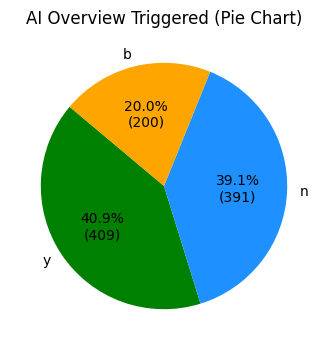

In [23]:
# Distribution of returned AI overview results (Y/N/B) for all queries

counts = queries_labeled_df['triggered_ai_overview'].value_counts()

# Pie chart
plt.figure(figsize=(4, 4))
plt.pie(
    counts,
    labels=["y", "n", "b"],
    autopct=lambda pct: f'{pct:.1f}%\n({int(round(pct/100.*sum(counts)))})',
    startangle=140,
    colors=["green", "dodgerblue", "orange"]
)
plt.title("AI Overview Triggered (Pie Chart)")
plt.show()

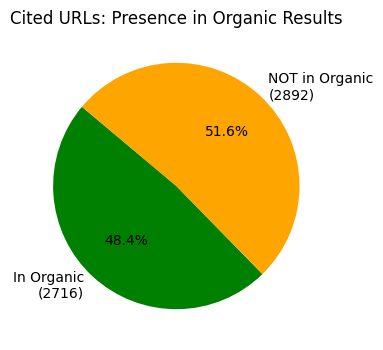

In [24]:
in_organic = 0
not_in_organic = 0

for _, row in responses_df.iterrows():
    try:
        refs = set(json.loads(row["references"]))
        organic = set(json.loads(row["organic_results"]))
    except Exception:
        continue

    for url in refs:
        if url in organic:
            in_organic += 1
        else:
            not_in_organic += 1

total = in_organic + not_in_organic
values = [in_organic, not_in_organic]
labels = [
    f"In Organic\n({in_organic})",
    f"NOT in Organic\n({not_in_organic})"
]

plt.figure(figsize=(4, 4))
plt.pie(
    values,
    labels=labels,
    autopct=lambda pct: f'{pct:.1f}%',
    colors=["green", "orange"],
    startangle=140
)
plt.title("Cited URLs: Presence in Organic Results")
plt.show()

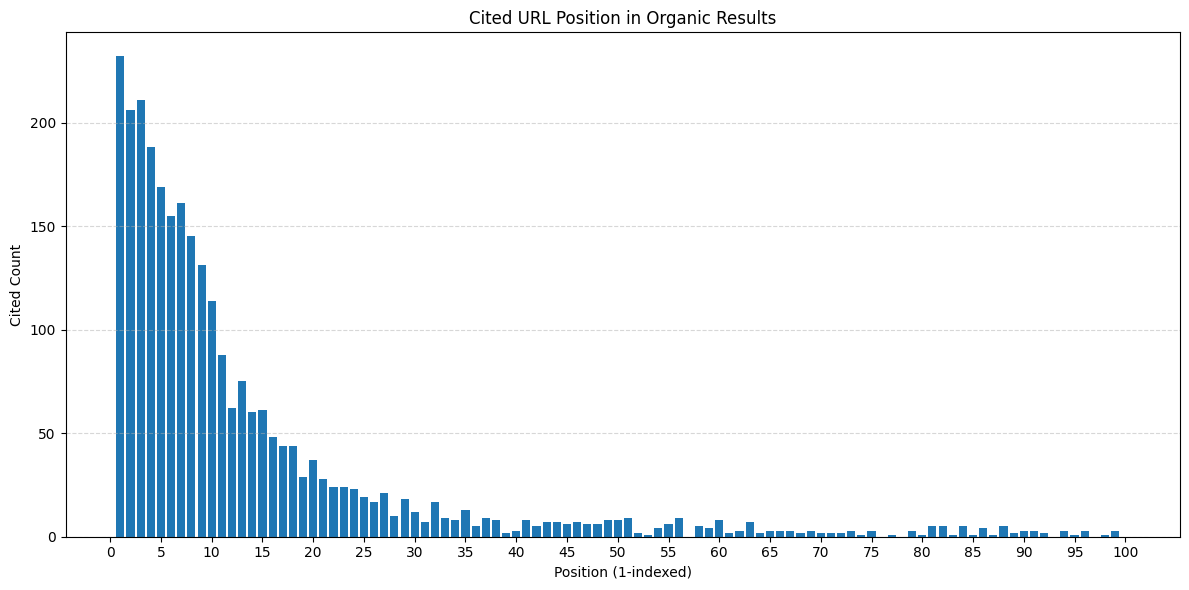

In [25]:
position_counter = Counter()

for _, row in responses_df.iterrows():
    try:
        refs = set(json.loads(row["references"]))
        organic = json.loads(row["organic_results"])
    except Exception:
        continue

    for i, url in enumerate(organic):
        if url in refs:
            position_counter[i + 1] += 1

positions = list(range(1, 101))
counts = [position_counter.get(i, 0) for i in positions]

plt.figure(figsize=(12, 6))
plt.bar(positions, counts)
plt.title("Cited URL Position in Organic Results")
plt.xlabel("Position (1-indexed)")
plt.ylabel("Cited Count")
plt.xticks(range(0, 101, 5))
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [26]:
# Identify classified and unclassified
classified_set = set(classified_urls_df["url"])
pool_set = set(urls_pool_df["url"])

failed_to_classify = pool_set - classified_set

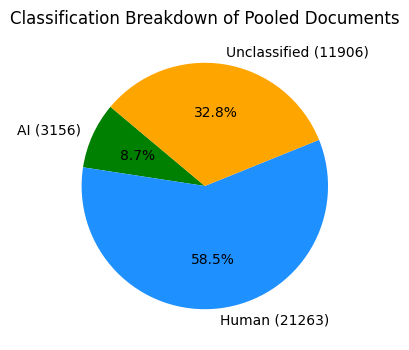

In [27]:
# Count AI and Human labels
ai_count = (classified_urls_df["ai_class"] == "AI").sum()
human_count = (classified_urls_df["ai_class"] == "Human").sum()
failed_count = len(failed_to_classify)

# Build pie chart
labels = [
    f"AI ({ai_count})",
    f"Human ({human_count})",
    f"Unclassified ({failed_count})"
]
values = [ai_count, human_count, failed_count]
colors = ["green", "dodgerblue", "orange"]

plt.figure(figsize=(4, 4))
plt.pie(
    values,
    labels=labels,
    autopct=lambda pct: f'{pct:.1f}%',
    colors=colors,
    startangle=140
)
plt.title("Classification Breakdown of Pooled Documents")
plt.show()

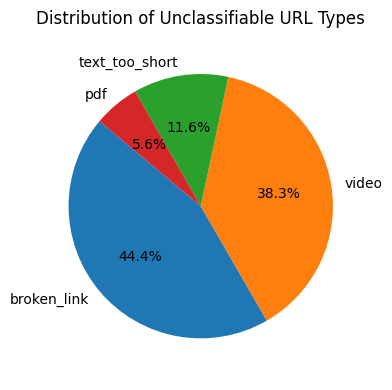

In [43]:
df = pd.read_csv(SAMPLE_DIR / "_scraped_unclassified.csv")
unclassified_urls_df = df[df["url"].isin(failed_to_classify)]

# Function to classify each row
def classify_type(row):
    url = row["url"]
    typ = row["type"]

    # Video platforms
    if typ == "video" or any(domain in url.lower() for domain in ["youtube.com", "tiktok.com"]):
        return "video"
    
    # Error codes as broken links
    if typ == "error" or isinstance(typ, int) or (isinstance(typ, str) and typ.isdigit()):
        return "broken_link"
    
    # Known types
    if typ == "pdf":
        return "pdf"
    elif typ == "too_short":
        return "text_too_short"

# Apply the classification
unclassified_urls_df = unclassified_urls_df.copy()
unclassified_urls_df["category"] = unclassified_urls_df.apply(classify_type, axis=1)

# Count the categories
category_counts = unclassified_urls_df["category"].value_counts()

# Plot pie chart
plt.figure(figsize=(4, 4))
plt.pie(category_counts, labels=category_counts.index, autopct='%1.1f%%', startangle=140)
plt.title("Distribution of Unclassifiable URL Types")
plt.axis("equal")
plt.tight_layout()
plt.show()


P(AI | cited): 9.13%
P(Human | cited): 64.36%
P(Unclassified | cited): 26.51%


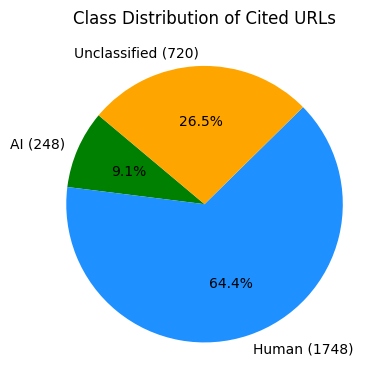

In [45]:
# Load data
classified_df = classified_urls_df
responses_df = pd.read_csv(SAMPLE_DIR / "_responses.csv")

# Build lookup sets
ai_urls = set(classified_df[classified_df["ai_class"] == "AI"]["url"])
human_urls = set(classified_df[classified_df["ai_class"] == "Human"]["url"])
classified_urls = ai_urls | human_urls

# Count citations by class
ai_cited = 0
human_cited = 0
unclassified_cited = 0
total_cited = 0

for _, row in responses_df.iterrows():
    try:
        refs = set(json.loads(row["references"]))
        organic = set(json.loads(row["organic_results"]))
        matched = refs & organic
    except Exception:
        continue

    for url in matched:
        total_cited += 1
        if url in ai_urls:
            ai_cited += 1
        elif url in human_urls:
            human_cited += 1
        else:
            unclassified_cited += 1

# Probabilities
p_ai = ai_cited / total_cited if total_cited else 0
p_human = human_cited / total_cited if total_cited else 0
p_unclassified = unclassified_cited / total_cited if total_cited else 0

print("P(AI | cited):", f"{p_ai * 100:.2f}%")
print("P(Human | cited):", f"{p_human * 100:.2f}%")
print("P(Unclassified | cited):", f"{p_unclassified * 100:.2f}%")

# Pie chart values and labels
values = [ai_cited, human_cited, unclassified_cited]
labels = [
    f"AI ({ai_cited})",
    f"Human ({human_cited})",
    f"Unclassified ({unclassified_cited})"
]
colors = ["green", "dodgerblue", "orange"]

# Plot
plt.figure(figsize=(4, 4))
plt.pie(
    values,
    labels=labels,
    autopct=lambda pct: f"{pct:.1f}%",
    colors=colors,
    startangle=140
)
plt.title("Class Distribution of Cited URLs")
plt.tight_layout()
plt.show()

In [30]:
all_urls = set(urls_pool_df["url"])

# Define classified sets
ai_urls = set(classified_urls_df[classified_urls_df["ai_class"] == "AI"]["url"])
human_urls = set(classified_urls_df[classified_urls_df["ai_class"] == "Human"]["url"])
classified_urls = ai_urls | human_urls

# Define unclassified set
unclassified_urls = all_urls - classified_urls

# Collect cited URLs (refs ∩ organic)
cited_urls = set()
for _, row in responses_df.iterrows():
    try:
        refs = set(json.loads(row["references"]))
        organic = set(json.loads(row["organic_results"]))
        cited_urls.update(refs & organic)
    except Exception:
        continue

# Intersections
cited_ai = len(cited_urls & ai_urls)
cited_human = len(cited_urls & human_urls)
cited_unclassified = len(cited_urls & unclassified_urls)

total_ai = len(ai_urls)
total_human = len(human_urls)
total_unclassified = len(unclassified_urls)

# Probabilities
p_ai = cited_ai / total_ai if total_ai else 0
p_human = cited_human / total_human if total_human else 0
p_unclassified = cited_unclassified / total_unclassified if total_unclassified else 0

# Output
print("P(cited | AI-generated):", f"{p_ai * 100:.2f}%")
print("P(cited | Human-written):", f"{p_human * 100:.2f}%")
print("P(cited | Unclassified):", f"{p_unclassified * 100:.2f}%")

P(cited | AI-generated): 7.86%
P(cited | Human-written): 8.18%
P(cited | Unclassified): 5.92%


In [31]:
# Probability of being cited *per organic document occurrence*

# Build lookup
ai_urls = set(classified_urls_df[classified_urls_df["ai_class"] == "AI"]["url"])
human_urls = set(classified_urls_df[classified_urls_df["ai_class"] == "Human"]["url"])

# Counters
ai_organic_count = 0
ai_cited_count = 0
human_organic_count = 0
human_cited_count = 0
total_organic_count = 0
total_cited_count = 0

# Add unclassified counters
unclassified_organic_count = 0
unclassified_cited_count = 0

for _, row in responses_df.iterrows():
    try:
        refs = set(json.loads(row["references"]))
        organic = json.loads(row["organic_results"])
    except Exception:
        continue

    for url in organic:
        total_organic_count += 1
        if url in refs:
            total_cited_count += 1

        if url in ai_urls:
            ai_organic_count += 1
            if url in refs:
                ai_cited_count += 1
        elif url in human_urls:
            human_organic_count += 1
            if url in refs:
                human_cited_count += 1
        else:
            unclassified_organic_count += 1
            if url in refs:
                unclassified_cited_count += 1

# Probabilities
p_overall = total_cited_count / total_organic_count if total_organic_count else 0
p_ai = ai_cited_count / ai_organic_count if ai_organic_count else 0
p_human = human_cited_count / human_organic_count if human_organic_count else 0
p_unclassified = unclassified_cited_count / unclassified_organic_count if unclassified_organic_count else 0

# Print
print("P(cited | appeared in organic):", f"{p_overall * 100:.2f}%")
print("P(cited | appeared in organic AND AI-classified):", f"{p_ai * 100:.2f}%")
print("P(cited | appeared in organic AND Human-classified):", f"{p_human * 100:.2f}%")
print("P(cited | appeared in organic AND Unclassified):", f"{p_unclassified * 100:.2f}%")


P(cited | appeared in organic): 3.39%
P(cited | appeared in organic AND AI-classified): 9.82%
P(cited | appeared in organic AND Human-classified): 8.80%
P(cited | appeared in organic AND Unclassified): 1.27%
